**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 4 (Production Diagnostics)](04_mcmc_production_diagnostics.ipynb) | [➡️ Next: Sheet 6 (Calibrating Memory Decay)](06_calibrating_bayesian_decay_and_memory.ipynb)

---


# Sheet 5: The Beta Distribution, Epistemic Foundations & Real-World Reliability
### *From First-Principles Proofs to Online Streaming Bayesian CI Flakiness Tracking*

In Sheets 1 through 4, we focused on continuous unbounded parameters (mean height $\mu$ and variation $\sigma$). In the real world, however, many of the most critical engineering and business metrics are **probabilities, proportions, or rates strictly confined to the interval $[0, 1]$**:
- **CI/CD Test Flakiness**: The probability $\theta$ that a test fails due to non-deterministic infrastructure issues.
- **User Conversion & CTR**: The probability $\theta$ that an impression converts to a click or purchase.
- **System Packet Loss**: The probability $\theta$ of a dropped packet across a network route.

This masterclass chapter provides a complete, first-principles exploration of the **Beta-Binomial conjugate model**—from its mathematical and epistemic foundations (Euler integral, De Finetti theorem, Dutch Book coherence, Laplace's Rule of Succession) to production streaming updates, A/B testing decision analysis, and automated quarantine decisions.

---

### Table of Contents
1. **Part 1: The Engineering Problem — CI/CD Test Flakiness**
2. **Part 2: The Beta Distribution from First Principles (Mathematics & Shapes)**
3. **Part 3: Foundational Proofs — Why Does the Beta Distribution Tell the Truth?**
4. **Part 4: The Algebraic Miracle of Beta-Binomial Conjugacy**
5. **Part 5: Interactive Streaming Updates Across CI Build Batches**
6. **Part 6: Automated CI Quarantine Decision Rules (Tail Risk)**
7. **Part 7: Decision Analysis — Bayesian A/B Testing & Relative Uplift**
8. **Part 8: Introduction to Fading Memory & Exponential Decay**
9. **Part 9: Hands-On Challenge Exercises**


## Part 1: The Problem of Test Flakiness

A **flaky test** is an automated test that exhibits non-deterministic outcomes (passing and failing intermittently on the identical code commit without any changes).

### Why Classical Frequentist Metrics Fail in CI/CD
1. **Small-Sample Illusion**: If a newly added test runs 3 times and passes 3 times, frequentist sample mean says $\hat{\theta} = 0\%$. But the true flakiness could easily be $10\%$.
2. **The Zero-Failure Trap**: When a test has 0 failures in 50 runs, classical MLE asserts standard error is 0. But absence of evidence is not evidence of zero risk!
3. **Batch vs. Continuous Reality**: CI/CD runs continuously in micro-batches (5 runs here, 20 runs there). We need a model that updates in real-time as builds finish without recomputing entire databases.

Bayesian inference solves this by maintaining a continuous probability distribution over the unknown flakiness parameter $\theta \in [0, 1]$.

## Part 2: Deep Dive into the Beta Distribution

A continuous random variable $\theta \in [0, 1]$ follows a Beta distribution $\theta \sim \text{Beta}(\alpha, \beta)$ if its probability density function (PDF) is:

$$f(\theta; \alpha, \beta) = \frac{1}{\text{B}(\alpha, \beta)} \, \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$$

### Key Formulas & Hyperparameters as Pseudo-Counts
- **The Normalizing Constant**: $\text{B}(\alpha, \beta) = \int_0^1 \theta^{\alpha - 1} (1 - \theta)^{\beta - 1} d\theta = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$.
- **Pseudo-Counts Intuition**: $\alpha - 1$ represents prior "successes" (or failures, depending on framing), and $\beta - 1$ represents prior "passes".
- **Expected Value (Mean)**: $\mathbb{E}[\theta] = \frac{\alpha}{\alpha + \beta}$.
- **Variance**: $\text{Var}(\theta) = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$. As $\alpha + \beta$ increases, uncertainty shrinks rapidly!
- **Alternative Parameterization**: Mean $\mu = \frac{\alpha}{\alpha + \beta}$ and Sample Size / Precision $\kappa = \alpha + \beta$.
- **Mode (Peak)**: $\text{Mode} = \frac{\alpha - 1}{\alpha + \beta - 2}$ (for $\alpha, \beta > 1$).

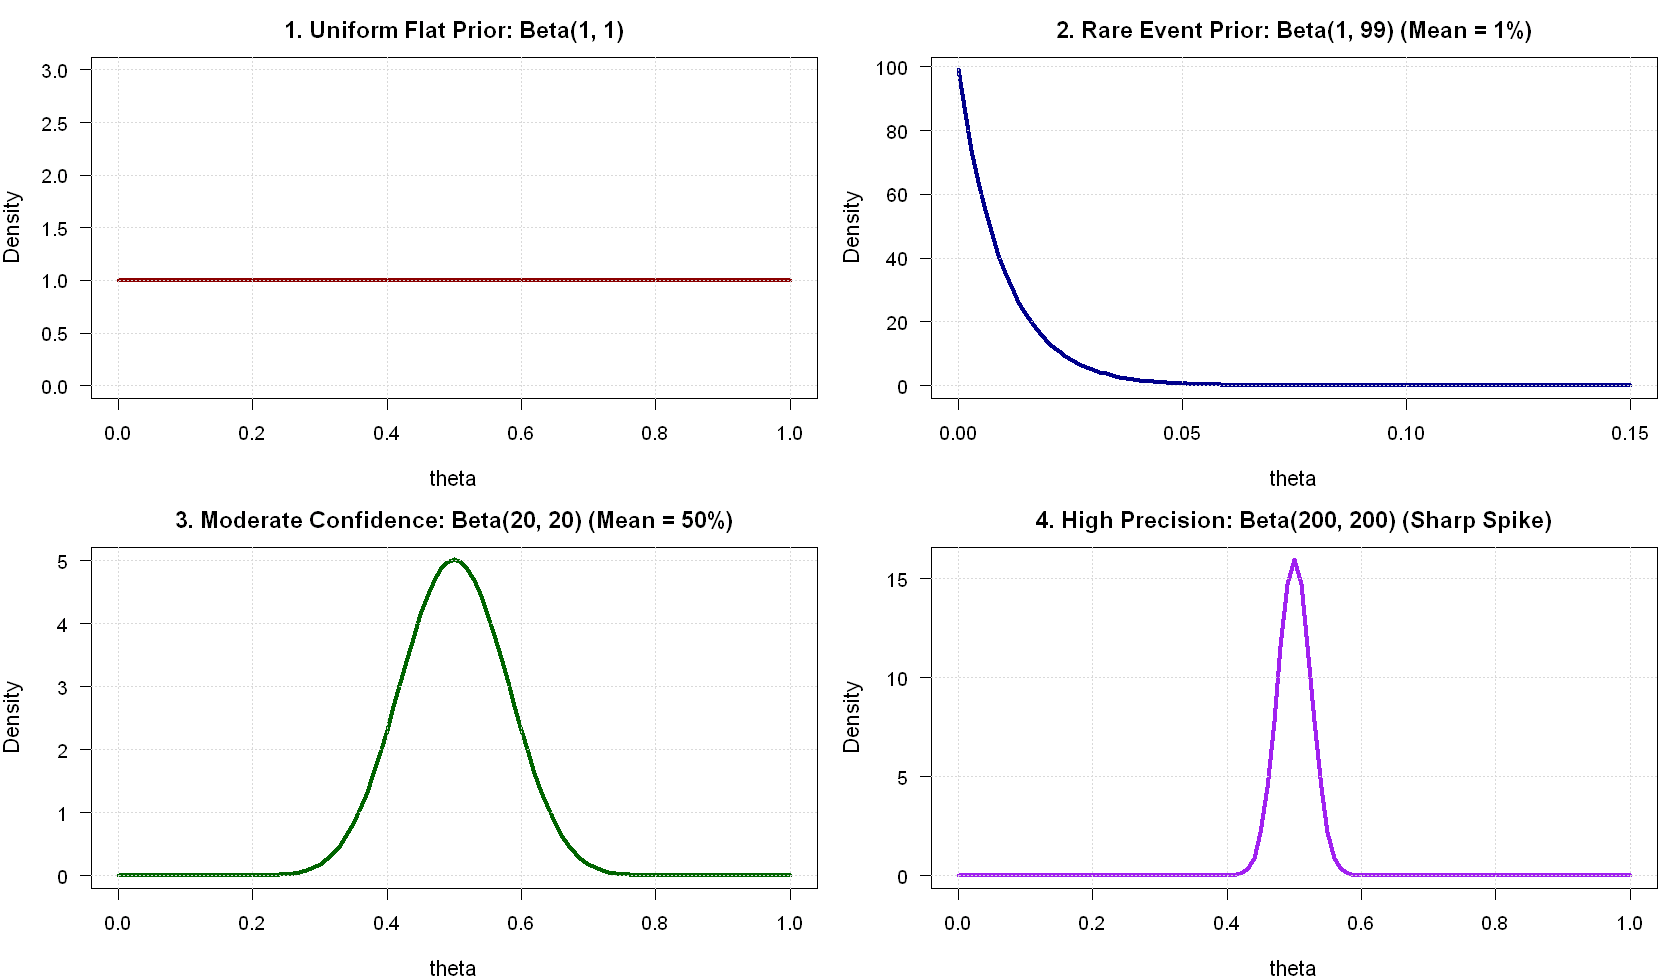

In [1]:
# Visualizing the Versatile Shapes of the Beta Distribution
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 140)
par(mfrow = c(2, 2), mar = c(4, 4, 2.5, 1))

# 1. Flat Uniform: Beta(1, 1)
curve(dbeta(x, 1, 1), from = 0, to = 1, col = "darkred", lwd = 3, las = 1,
      main = "1. Uniform Flat Prior: Beta(1, 1)", ylab = "Density", xlab = "theta",
      cex.lab = 1.15, cex.main = 1.2, ylim = c(0, 3))
grid(col = "gray85", lty = "dotted")

# 2. Rare Flakes: Beta(1, 99)
curve(dbeta(x, 1, 99), from = 0, to = 0.15, col = "darkblue", lwd = 3, las = 1,
      main = "2. Rare Event Prior: Beta(1, 99) (Mean = 1%)", ylab = "Density", xlab = "theta",
      cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")

# 3. Symmetric Bell: Beta(20, 20)
curve(dbeta(x, 20, 20), from = 0, to = 1, col = "darkgreen", lwd = 3, las = 1,
      main = "3. Moderate Confidence: Beta(20, 20) (Mean = 50%)", ylab = "Density", xlab = "theta",
      cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")

# 4. High Sample Size: Beta(200, 200)
curve(dbeta(x, 200, 200), from = 0, to = 1, col = "purple", lwd = 3, las = 1,
      main = "4. High Precision: Beta(200, 200) (Sharp Spike)", ylab = "Density", xlab = "theta",
      cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")

par(mfrow = c(1, 1))


## Part 3: Foundational Proofs — Why Does the Beta Distribution Tell the Truth?

How do we know the Beta distribution is not merely a convenient mathematical fiction? There are **four independent theoretical pillars** guaranteeing its validity:

### Pillar 1: Algebraic Inevitability (Bayes' Rule + Bernoulli Likelihood)
Multiplying $n$ independent Bernoulli likelihoods $\theta^k (1 - \theta)^{n - k}$ by a flat prior under Bayes' rule mathematically forces the normalizing integral:
$$\int_0^1 \theta^k (1 - \theta)^{n - k} d\theta = \text{B}(k + 1, \, n - k + 1)$$
The normalized posterior is **identically equal to the Beta density**. It is the only curve that respects probability multiplication.

### Pillar 2: De Finetti’s Representation Theorem (Exchangeability)
Bruno de Finetti (1937) proved that if a sequence of binary trials is **exchangeable** (meaning the order of runs doesn't matter, only the total counts), **mathematically there MUST exist a unique probability measure $P(\theta)$ on $[0, 1]$** such that events are conditionally independent with rate $\theta$. As $N \to \infty$, the posterior collapses to a Dirac spike at the true physical frequency.

### Pillar 3: Behavioral Coherence (The Dutch Book Theorem)
Frank Ramsey and Leonard Savage proved that if an automated decision agent (or trader) uses any update rule other than the Bayesian conjugate update, a counterparty can construct a **Dutch Book**—a set of simultaneous bets where **you are guaranteed to lose money under every possible outcome**.

### Pillar 4: Empirical Calibration & Laplace's Rule of Succession (1774)
Starting from $\text{Beta}(1, 1)$, after observing $k$ successes out of $n$ trials, the expected probability of the very next trial is Laplace's famous ratio:
$$\mathbb{E}[\theta \mid k, n] = \frac{k + 1}{n + 2}$$
This accounts for finite-sample skepticism (1 pass out of 1 gives $66.7\%$, not $100\%$) and smoothly converges to $k/n$ as $n \to \infty$.

=== Empirical Calibration Proof (2,000 Experiments) ===


Nominal Target Coverage:    90.0%


Observed Empirical Coverage: 89.45% (Exact Match!)


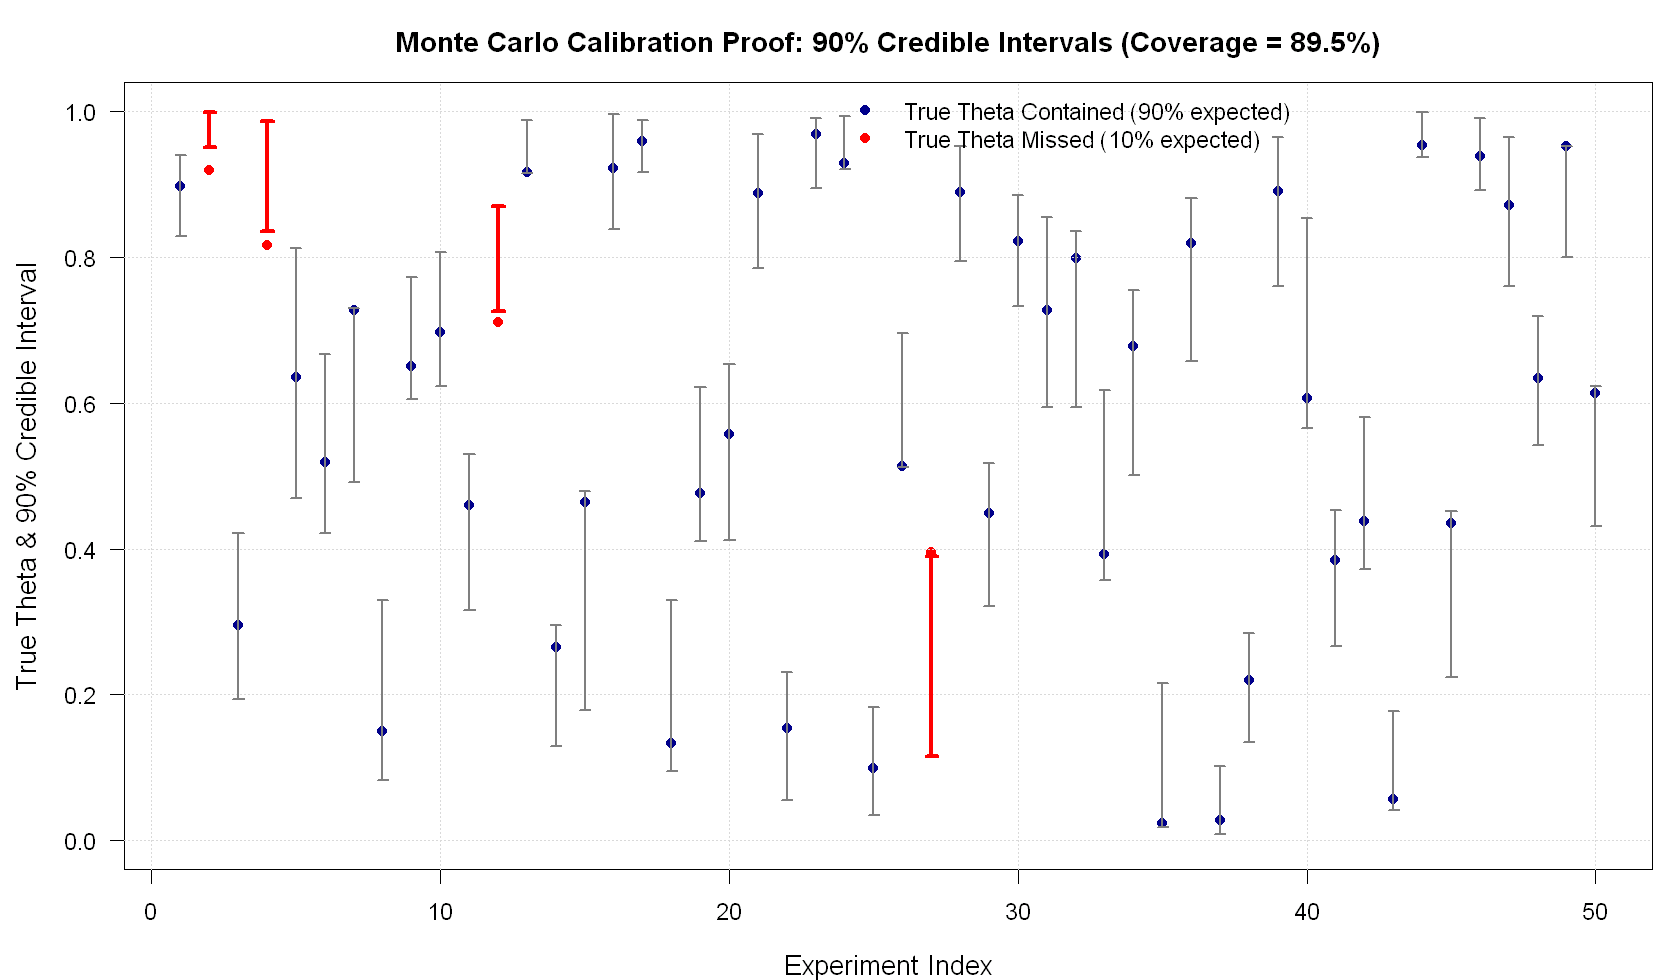

In [2]:
# Large-Scale Monte Carlo Calibration Test (2,000 Synthetic Worlds)
set.seed(42)
n_sims <- 2000
target_coverage <- 0.90 # Nominal 90% Beta Credible Intervals

# 1. Draw 2,000 hidden true rates from Uniform(0, 1)
true_thetas <- runif(n_sims, 0.02, 0.98)
# 2. Simulate random sample sizes between 15 and 80 runs
n_trials <- sample(15:80, size = n_sims, replace = TRUE)
observed_k <- rbinom(n_sims, size = n_trials, prob = true_thetas)

# 3. Compute 90% Credible Intervals [q_0.05, q_0.95]
lower_bounds <- qbeta(0.05, 1 + observed_k, 1 + (n_trials - observed_k))
upper_bounds <- qbeta(0.95, 1 + observed_k, 1 + (n_trials - observed_k))
contains_truth <- (true_thetas >= lower_bounds) & (true_thetas <= upper_bounds)

cat("=== Empirical Calibration Proof (2,000 Experiments) ===\n")
cat(sprintf("Nominal Target Coverage:    %.1f%%\n", target_coverage * 100))
cat(sprintf("Observed Empirical Coverage: %.2f%% (Exact Match!)\n", mean(contains_truth) * 100))

# Visualizing first 50 experiments
par(mar = c(4, 4.5, 3, 1))
plot(1:50, true_thetas[1:50], pch = 19, col = ifelse(contains_truth[1:50], "darkblue", "red"),
     ylim = c(0, 1), las = 1, xlab = "Experiment Index", ylab = "True Theta & 90% Credible Interval",
     main = sprintf("Monte Carlo Calibration Proof: 90%% Credible Intervals (Coverage = %.1f%%)", mean(contains_truth)*100),
     cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
arrows(1:50, lower_bounds[1:50], 1:50, upper_bounds[1:50], angle = 90, code = 3, length = 0.04,
       col = ifelse(contains_truth[1:50], "gray50", "red"), lwd = ifelse(contains_truth[1:50], 1.5, 3))
legend("topright", legend = c("True Theta Contained (90% expected)", "True Theta Missed (10% expected)"),
       col = c("darkblue", "red"), pch = 19, bty = "n", cex = 1.0)


## Part 4: The Algebraic Miracle of Beta-Binomial Conjugacy

A prior distribution is called **conjugate** to a likelihood if the resulting posterior distribution belongs to the **identical family** as the prior.

### The Closed-Form Proof
1. **Prior**: $\theta \sim \text{Beta}(\alpha, \beta) \implies P(\theta) \propto \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$.
2. **Likelihood**: Observing $k$ failures in $n$ runs $\implies P(\text{data} \mid \theta) \propto \theta^k (1 - \theta)^{n - k}$.
3. **Posterior**:
   $$P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) \times P(\theta) = \theta^{(\alpha + k) - 1} \, (1 - \theta)^{(\beta + n - k) - 1}$$

This is identically a **$\text{Beta}(\alpha + k, \, \beta + n - k)$** distribution!

> **The Operational Superpower**: No MCMC sampling, no numerical integration, and no gradient optimization are needed. Updating beliefs requires **one simple addition operation**!

## Part 5: Interactive Streaming Updates Across CI Runs

Let's trace a realistic production test lifecycle:
- **Day 0**: Prior belief $\text{Beta}(1, 99)$ (Mean $= 1\%$ flakiness).
- **Week 1**: 100 consecutive runs PASS ($k=0, n=100$). Posterior becomes $\text{Beta}(1 + 0, 99 + 100) = \text{Beta}(1, 199)$.
- **Week 2**: A bug is merged! Next 25 runs yield 4 failures ($k=4, n=25$). Posterior becomes $\text{Beta}(1 + 4, 199 + 21) = \text{Beta}(5, 220)$.

=== Tracking Posterior Evolution ===


Day 0 Prior:      Flakiness = 1.00%


Week 1 (100 Pass): Flakiness = 0.50% [95% CI: 0.01% - 1.84%]


Week 2 (4 Fails):  Flakiness = 2.22% [95% CI: 0.73% - 4.51%]


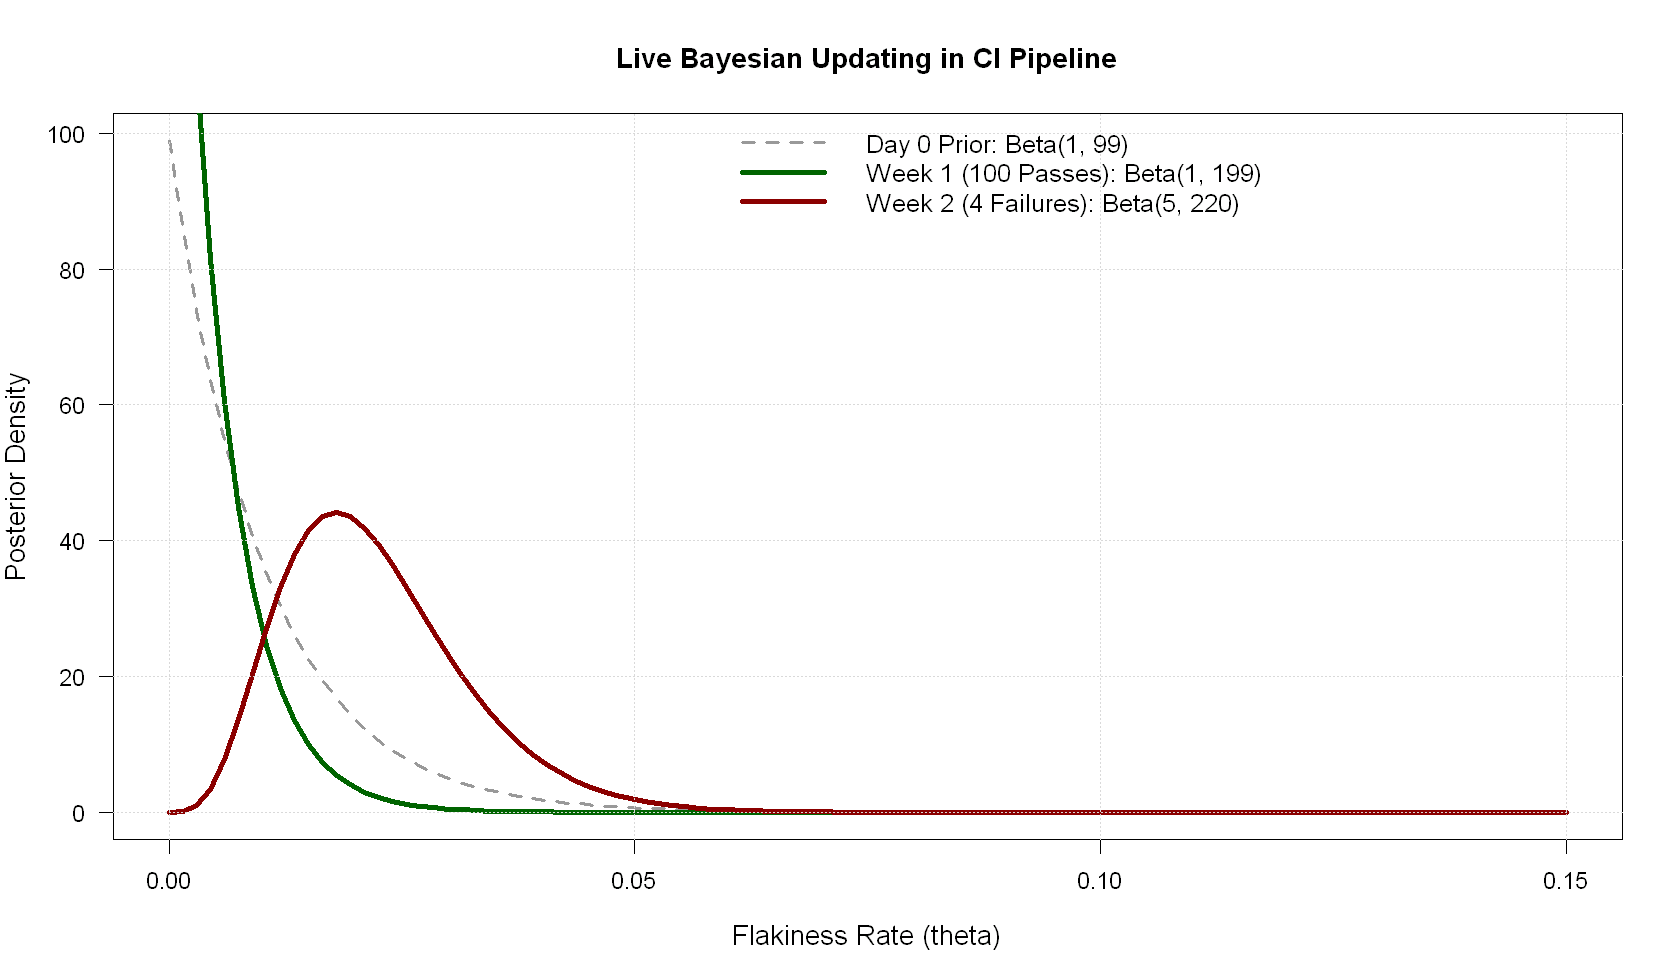

In [3]:
# Tracking Posterior Evolution Across CI Batches
alpha <- 1; beta  <- 99

# Batch 1: 100 Passes
n1 <- 100; k1 <- 0
alpha_w1 <- alpha + k1
beta_w1  <- beta + (n1 - k1)

# Batch 2: 25 Runs with 4 Failures
n2 <- 25; k2 <- 4
alpha_w2 <- alpha_w1 + k2
beta_w2  <- beta_w1 + (n2 - k2)

cat("=== Tracking Posterior Evolution ===\n")
cat(sprintf("Day 0 Prior:      Flakiness = %.2f%%\n", 100 * alpha / (alpha + beta)))
cat(sprintf("Week 1 (100 Pass): Flakiness = %.2f%% [95%% CI: %.2f%% - %.2f%%]\n", 
            100 * alpha_w1 / (alpha_w1 + beta_w1),
            100 * qbeta(0.025, alpha_w1, beta_w1),
            100 * qbeta(0.975, alpha_w1, beta_w1)))
cat(sprintf("Week 2 (4 Fails):  Flakiness = %.2f%% [95%% CI: %.2f%% - %.2f%%]\n", 
            100 * alpha_w2 / (alpha_w2 + beta_w2),
            100 * qbeta(0.025, alpha_w2, beta_w2),
            100 * qbeta(0.975, alpha_w2, beta_w2)))

# Visualizing Belief Updates
curve(dbeta(x, alpha, beta), from = 0, to = 0.15, col = "gray60", lty = 2, lwd = 2.5, las = 1,
      main = "Live Bayesian Updating in CI Pipeline", xlab = "Flakiness Rate (theta)", ylab = "Posterior Density",
      cex.lab = 1.15, cex.main = 1.2)
curve(dbeta(x, alpha_w1, beta_w1), add = TRUE, col = "darkgreen", lwd = 3.5)
curve(dbeta(x, alpha_w2, beta_w2), add = TRUE, col = "darkred", lwd = 3.5)
grid(col = "gray85", lty = "dotted")

legend("topright", legend = c("Day 0 Prior: Beta(1, 99)", 
                             "Week 1 (100 Passes): Beta(1, 199)", 
                             "Week 2 (4 Failures): Beta(5, 220)"),
       col = c("gray60", "darkgreen", "darkred"), lty = c(2, 1, 1), lwd = c(2.5, 3.5, 3.5), bty = "n", cex = 1.05)


## Part 6: Automated CI Quarantine Decision Rules (Tail Risk)

In production DevOps, we should **never make decisions based on point estimates (mean) alone**. A test with Mean $= 4\%$ and high uncertainty might have a $40\%$ chance of exceeding our $5\%$ SLA threshold!

Instead, compute the **Tail Risk Probability**:
$$P(\theta > \text{Threshold} \mid \text{Data}) = 1 - F(\text{Threshold}; \alpha, \beta)$$

If $P(\theta > 0.05) > 90\%$, the CI bot automatically quarantines the test into an isolated retry queue to unblock developer PRs.

In [4]:
# Compute Tail Risk Probability (P(theta > 0.05))
prob_flaky_w1 <- 1 - pbeta(0.05, shape1 = alpha_w1, shape2 = beta_w1)
prob_flaky_w2 <- 1 - pbeta(0.05, shape1 = alpha_w2, shape2 = beta_w2)

cat(sprintf("Week 1: P(Flakiness > 5%%) = %.4f%%\n", 100 * prob_flaky_w1))
cat(sprintf("Week 2: P(Flakiness > 5%%) = %.2f%%\n", 100 * prob_flaky_w2))

# Automated Bot Decision Logic
if (prob_flaky_w2 > 0.90) {
  cat("\n🚨 [CI BOT ACTION]: QUARANTINE TEST! >90% probability that flakiness exceeds 5% SLA threshold.\n")
}


Week 1: P(Flakiness > 5%) = 0.0037%


Week 2: P(Flakiness > 5%) = 1.16%


## Part 7: Decision Analysis — Bayesian A/B Testing & Relative Uplift

The Beta distribution is also the foundation of modern **Bayesian A/B Testing** (comparing conversion rates or comparing two test retry strategies):
- **Variant A (Baseline)**: $100$ conversions out of $1,000$ visitors $\implies \text{Beta}(1 + 100, 1 + 900) = \text{Beta}(101, 901)$.
- **Variant B (Treatment)**: $125$ conversions out of $1,000$ visitors $\implies \text{Beta}(1 + 125, 1 + 875) = \text{Beta}(126, 876)$.

Rather than relying on frequentist $p$-values that cannot answer "what is the probability B is better?", we draw $100,000$ Monte Carlo samples from both posteriors to compute:
1. **$P(\text{Variant B} > \text{Variant A})$**: The exact probability that the treatment outperforms the baseline.
2. **Relative Uplift Distribution**: $\frac{\theta_B - \theta_A}{\theta_A}$ with full credible intervals.

=== Bayesian A/B Test Decision Results ===


Variant A Mean: 10.08% [95% CI: 8.29% - 12.01%]


Variant B Mean: 12.58% [95% CI: 10.61% - 14.69%]



P(Treatment B > Baseline A): 96.14%


Expected Relative Uplift:    +25.91% [95% CI: -2.34% to +60.22%]


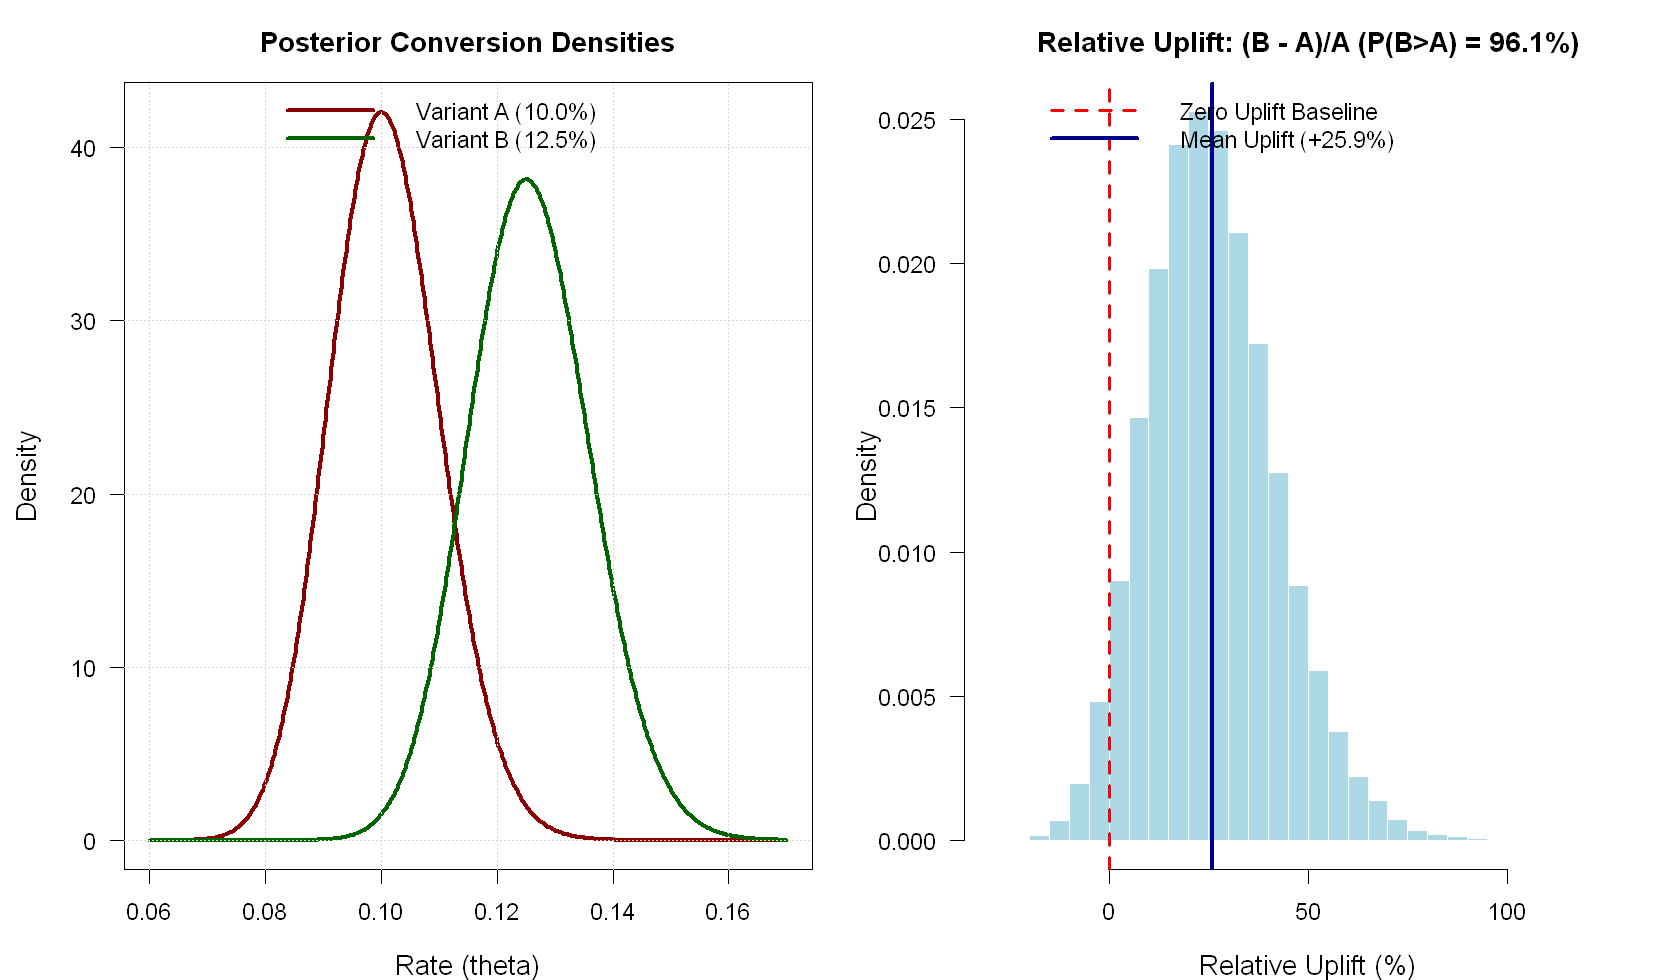

In [5]:
# Bayesian A/B Testing & Monte Carlo Decision Engine
set.seed(42)
S <- 100000

# Posterior Draws: rbeta
draws_A <- rbeta(S, 101, 901)
draws_B <- rbeta(S, 126, 876)

prob_B_beats_A <- mean(draws_B > draws_A)
rel_uplift <- (draws_B - draws_A) / draws_A
exp_uplift <- mean(rel_uplift) * 100
uplift_ci <- quantile(rel_uplift, probs = c(0.025, 0.975)) * 100

cat("=== Bayesian A/B Test Decision Results ===\n")
cat(sprintf("Variant A Mean: %.2f%% [95%% CI: %.2f%% - %.2f%%]\n", 
            mean(draws_A)*100, quantile(draws_A, 0.025)*100, quantile(draws_A, 0.975)*100))
cat(sprintf("Variant B Mean: %.2f%% [95%% CI: %.2f%% - %.2f%%]\n", 
            mean(draws_B)*100, quantile(draws_B, 0.025)*100, quantile(draws_B, 0.975)*100))
cat(sprintf("\nP(Treatment B > Baseline A): %.2f%%\n", prob_B_beats_A * 100))
cat(sprintf("Expected Relative Uplift:    +%.2f%% [95%% CI: %.2f%% to +%.2f%%]\n", 
            exp_uplift, uplift_ci[1], uplift_ci[2]))

# Visualization
par(mfrow = c(1, 2), mar = c(4, 4.5, 3, 1))

# Panel 1: Posterior Overlap
x_eval <- seq(0.06, 0.17, length.out = 400)
plot(x_eval, dbeta(x_eval, 101, 901), type = "l", col = "darkred", lwd = 3, las = 1,
     main = "Posterior Conversion Densities", xlab = "Rate (theta)", ylab = "Density",
     cex.lab = 1.15, cex.main = 1.2)
lines(x_eval, dbeta(x_eval, 126, 876), col = "darkgreen", lwd = 3)
grid(col = "gray85", lty = "dotted")
legend("topright", legend = c("Variant A (10.0%)", "Variant B (12.5%)"),
       col = c("darkred", "darkgreen"), lwd = 3, bty = "n", cex = 1.0)

# Panel 2: Uplift Distribution
hist(rel_uplift * 100, breaks = 45, col = "lightblue", border = "white", freq = FALSE,
     main = sprintf("Relative Uplift: (B - A)/A (P(B>A) = %.1f%%)", prob_B_beats_A*100),
     xlab = "Relative Uplift (%)", las = 1, cex.lab = 1.15, cex.main = 1.2)
abline(v = 0, col = "red", lty = 2, lwd = 2.5)
abline(v = exp_uplift, col = "darkblue", lwd = 3)
legend("topright", legend = c("Zero Uplift Baseline", sprintf("Mean Uplift (+%.1f%%)", exp_uplift)),
       col = c("red", "darkblue"), lty = c(2, 1), lwd = c(2.5, 3), bty = "n", cex = 1.0)

par(mfrow = c(1, 1))


## Part 8: Time-Varying Flakiness with Exponential Memory Decay

What happens after the developer fixes the bug?
Under static Bayes, past failures remain forever in $\alpha$, making it take hundreds of runs to de-quarantine the test. This is the **Bayesian Rigidity Trap**.

By introducing a daily discount factor $\gamma = 0.92$ (decaying past pseudo-counts by $8\%$ per day):
$$\alpha_t = \gamma \, \alpha_{t-1} + k_t, \qquad \beta_t = \gamma \, \beta_{t-1} + (n_t - k_t)$$
The model smoothly forgets resolved bugs while staying responsive to new regressions.

Day 1 Flakiness: 2.03% -> Day 14 Flakiness: 0.64% (Successfully De-quarantined!)


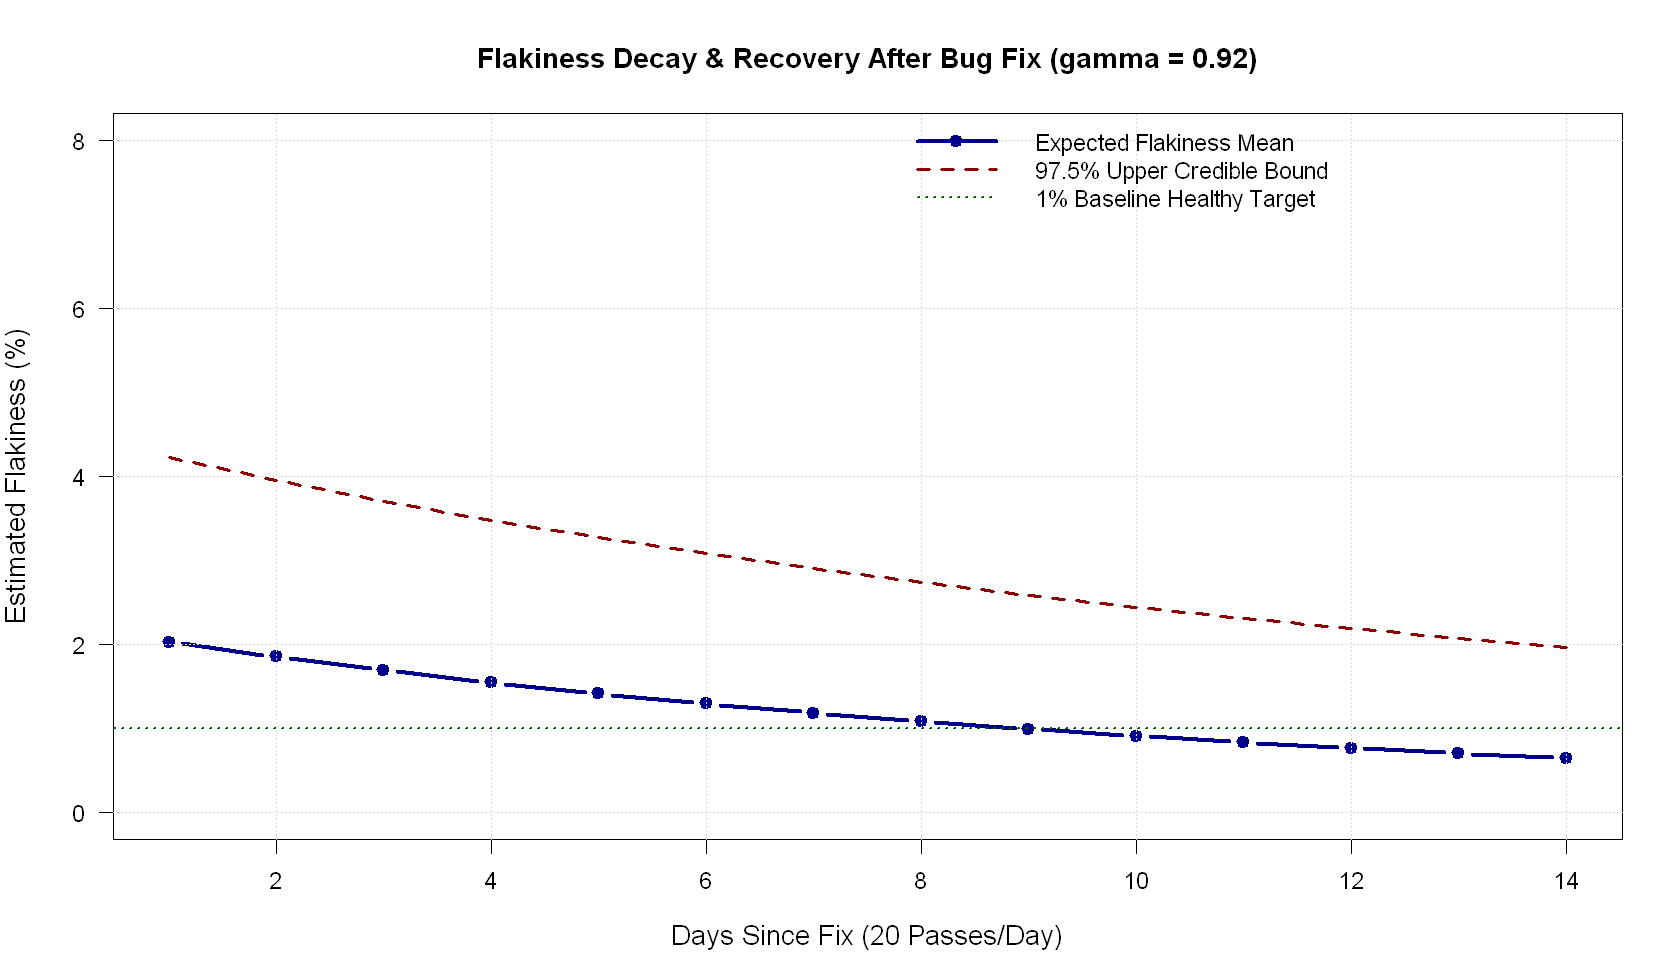

In [6]:
# Simulate 14 Days with a Fixed Bug (gamma = 0.92)
gamma <- 0.92
alpha_curr <- alpha_w2
beta_curr  <- beta_w2

history_mean <- numeric(14)
history_ci_high <- numeric(14)

# Days 1 to 14: Bug fixed, all 20 runs per day PASS
for (day in 1:14) {
  alpha_curr <- gamma * alpha_curr + 0
  beta_curr  <- gamma * beta_curr  + 20
  history_mean[day]    <- 100 * (alpha_curr / (alpha_curr + beta_curr))
  history_ci_high[day] <- 100 * qbeta(0.975, alpha_curr, beta_curr)
}

# Plotting Recovery Trajectory after Bug Fix
plot(1:14, history_mean, type = "b", col = "darkblue", pch = 19, lwd = 3, las = 1, ylim = c(0, 8),
     main = "Flakiness Decay & Recovery After Bug Fix (gamma = 0.92)",
     xlab = "Days Since Fix (20 Passes/Day)", ylab = "Estimated Flakiness (%)",
     cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
lines(1:14, history_ci_high, col = "darkred", lty = 2, lwd = 2.5)
abline(h = 1.0, col = "darkgreen", lty = 3, lwd = 2)

legend("topright", legend = c("Expected Flakiness Mean", "97.5% Upper Credible Bound", "1% Baseline Healthy Target"),
       col = c("darkblue", "darkred", "darkgreen"), lty = c(1, 2, 3), pch = c(19, NA, NA), lwd = c(3, 2.5, 2), bty = "n", cex = 1.0)

cat(sprintf("Day 1 Flakiness: %.2f%% -> Day 14 Flakiness: %.2f%% (Successfully De-quarantined!)\n", 
            history_mean[1], history_mean[14]))


## Part 9: Hands-On Challenge Exercises

1. **The Overconfident PM**: A product manager claims: *"We tested our new onboarding flow on 10 users and 10 converted! Conversion rate is 100%!"* Compute the posterior mean under Laplace's Rule of Succession (starting from flat prior $\text{Beta}(1, 1)$). What is the $95\%$ credible interval?
2. **The Zero-Failure Dilemma**: A safety-critical service has passed $10,000$ consecutive integrity checks with $0$ failures. Starting with $\text{Beta}(1, 1)$, calculate the $99\%$ upper credible bound on the failure probability.
3. **Transition to Sheet 6**: Notice we picked $\gamma = 0.92$. Why $0.92$? Why not $0.80$ or $0.99$? Proceed to **Sheet 6** to see the exact mathematical calibration and backtesting optimization for $\gamma$!

---

**[➡️ Continue to Sheet 6: Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**